# Pheno-Boundary using SAM3

**Project:** Final project; SPEOPF_W25 - Agricultural Parcel Delineation  
**Study Area:** South Tyrol, Italy  
**Authors:** Ahmad Ahmad Abubakar, Ousama Bin Zamir  
**Model:** SAM3 from meta  
**Data:** Sentinel-2 L2A via EOPF STAC, 2020-2023

# Setup

In [ ]:
import sys, os, subprocess
import shutil

# mounting drive and root dir
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # Mounting Drive
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = '/content/drive/MyDrive/Pheno_boundary_detection_Pretrained_SamGeo3'
    if os.path.exists(REPO_ROOT):
        print(f"Directory '{REPO_ROOT}' already exists on Drive.")
        os.chdir(REPO_ROOT)
else:
  print('Running locally')
  REPO_ROOT = os.getcwd()
  print(f'Working directory: {REPO_ROOT}')

# installing dependencies
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'segment-geospatial[samgeo3]', 'segmentation-models-pytorch', 'leafmap', 'rasterio',
     'rioxarray', 'seaborn', 'tqdm', 'pystac-client'], # pystac-client
    check=True
)
print('Setup complete')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory '/content/drive/MyDrive/pheno-boundary' already exists on Drive.
Setup complete


## Check GPU

In [30]:
import torch
if torch.cuda.is_available():
    print(f"We got GPU here: {torch.cuda.get_device_name(0)}")
    print(f"memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected")

We got GPU here: Tesla T4
memory: 15.6 GB


## Libraries

In [57]:
import os, pickle, warnings, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd

import rasterio
from rasterio.transform import from_bounds
from scipy import ndimage as ndi

import leafmap
from samgeo import SamGeo3
import segmentation_models_pytorch as smp

# project modules
from src.data_loader import connect_stac_catalog, search_sentinel2, build_datacube
from src.preprocessing import apply_cloud_mask, prepare_ftw_input, compute_ndvi
from src.postprocessing import apply_vito_filter, postprocess_results, postprocess_all_years
from src.stability import (
    compute_stability_matrix, multi_year_change_analysis,
    classify_stability_zones, compute_persistence_index, summarize_stability
)
from src.validation import load_cadastre, rasterize_parcels, generate_full_report
from src.vectorization import vectorize_segments, find_most_stable_year, create_interactive_map
from src.visualization import plot_stability_matrix, plot_stability_zones

## Dir config

In [32]:
# defining paths
BASE_DIR    = os.getcwd()
DATA_DIR    = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR  = os.path.join(DATA_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
METRICS_DIR = os.path.join(OUTPUT_DIR, 'metrics')

# precomputed inputs
INPUTS_PKL  = os.path.join(DATA_DIR, 'outputs', 'ftw_inputs.pkl')
SAM3_VITO_PKL    = os.path.join(OUTPUT_DIR, 'sam3_vito_results.pkl')
SAM3_RESULTS_PKL = os.path.join(OUTPUT_DIR, 'sam3_raw_results.pkl')
SAM3_VAL_PKL     = os.path.join(OUTPUT_DIR, 'sam3_val_report.pkl')
SAM3_TIF_DIR     = 'sam3_input_geotiffs'
# shape file
CADASTRE_SHP = os.path.join(DATA_DIR, 'South_Tyrol_parcels.shp')

# if dir not there
os.makedirs(SAM3_TIF_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

for label, path in [('Outputs dir', OUTPUT_DIR),
                    ('Inputs pkl',  INPUTS_PKL)]:
    status = 'Founded' if os.path.exists(path) else 'Not there'
    print(f'  {label:<14}: {status}')

# main constant values
YEARS       = [2020, 2021, 2022, 2023]
AOI_BBOX    = [11.290770, 46.356466, 11.315060, 46.389037]
TARGET_CRS  = 'EPSG:32632'

  Outputs dir   : Founded
  Inputs pkl    : Founded


# Data

## Loading Data

In [33]:
STAC_URL   = 'https://stac.core.eopf.eodc.eu'
COLLECTION = 'sentinel-2-l2a'

catalog = connect_stac_catalog(STAC_URL)
print(f'Connected\nAvailable collections: {[c.id for c in catalog.get_collections()][:5]} …')

Connected
Available collections: ['sentinel-2-l2a', 'sentinel-1-l1-grd', 'sentinel-3-slstr-l2-lst', 'sentinel-3-slstr-l2-frp', 'sentinel-3-olci-l2-lfr'] …


In [34]:
items = search_sentinel2(
    catalog,
    bbox=AOI_BBOX,
    start_date='2019-12-31',
    end_date='2024-01-01',
    collection=COLLECTION,
)

print(f'Found {len(items)} Sentinel-2 scenes')

if items:
    item = items[0]
    print(f'ID    : {item["id"]}')
    print(f'Date  : {item["properties"]["datetime"]}')
    cloud_cover_val = item["properties"].get("eo:cloud_cover", "N/A")
    if isinstance(cloud_cover_val, (int, float)):
        print(f'Cloud cov: {cloud_cover_val:.1f}%')
    else:
        print(f'Cloud cov: {cloud_cover_val}%')

Found 546 Sentinel-2 scenes
ID    : S02MSIL2A_20231229T101431_0000_A022_T256
Date  : 2023-12-29T10:14:31.024000Z
Cloud cov: N/A%


In [35]:
# Data cube
RUN_DATA_LOADING = False # set True to rebuild from STAC newly

if RUN_DATA_LOADING:
    bands = ['b02', 'b03', 'b04', 'b08']
    datacube = build_datacube(
        items=items,
        bbox=AOI_BBOX,
        bands=bands,
        include_scl=True,
        parallel=True,
    )
    print(f'Datacube:{datacube}')
else:
    print(f'Pre-computed inputs location: {INPUTS_PKL}')

Pre-computed inputs location: /content/drive/MyDrive/pheno-boundary/data/outputs/ftw_inputs.pkl


## Preprocessing

In [36]:
RUN_PREPROCESSING = False  # Set True if you want to build data cube newly

if RUN_PREPROCESSING:
    datacube_masked = apply_cloud_mask(datacube)

    ftw_inputs = {}
    for year in YEARS:
        arr = prepare_ftw_input(
            datacube_masked,
            year=year,
            spring_months=[3, 4, 5],
            summer_months=[6, 7, 8],
            normalize_max=0.5,
        )
        ftw_inputs[year] = arr
        print(f'  {year}: input shape {arr.shape}, range [{arr.min():.3f}, {arr.max():.3f}]')

    with open(INPUTS_PKL, 'wb') as f:
        pickle.dump(ftw_inputs, f)
    print(f'\nSaved FTW inputs → {INPUTS_PKL}')

else:
    with open(INPUTS_PKL, 'rb') as f:
        ftw_inputs = pickle.load(f)
    print('Loaded pre-computed inputs:')
    for year, arr in ftw_inputs.items():
        print(f'  {year}: {arr.shape}, {arr.dtype} [{arr.min():.3f}, {arr.max():.3f}]')

Loaded pre-computed inputs:
  2020: (8, 368, 177), float32 [0.021, 1.000]
  2021: (8, 368, 177), float32 [0.021, 1.000]
  2022: (8, 368, 177), float32 [0.017, 1.000]
  2023: (8, 368, 177), float32 [0.020, 1.000]


In [37]:
# fix
BAND_FIX = [2, 1, 0, 3, 6, 5, 4, 7]
inputs = {}
spring_rgb = {}
summer_rgb = {}

for year in YEARS:
    cor = ftw_inputs[year][BAND_FIX]
    inputs[year] = cor
    spring_rgb[year] = cor[0:4]
    summer_rgb[year] = cor[4:8]

H, W = ftw_inputs[YEARS[0]].shape[1], ftw_inputs[YEARS[0]].shape[2]
print(f"Dictionaries restored for years: {list(spring_rgb.keys())}")

Dictionaries restored for years: [2020, 2021, 2022, 2023]


## Visualizing

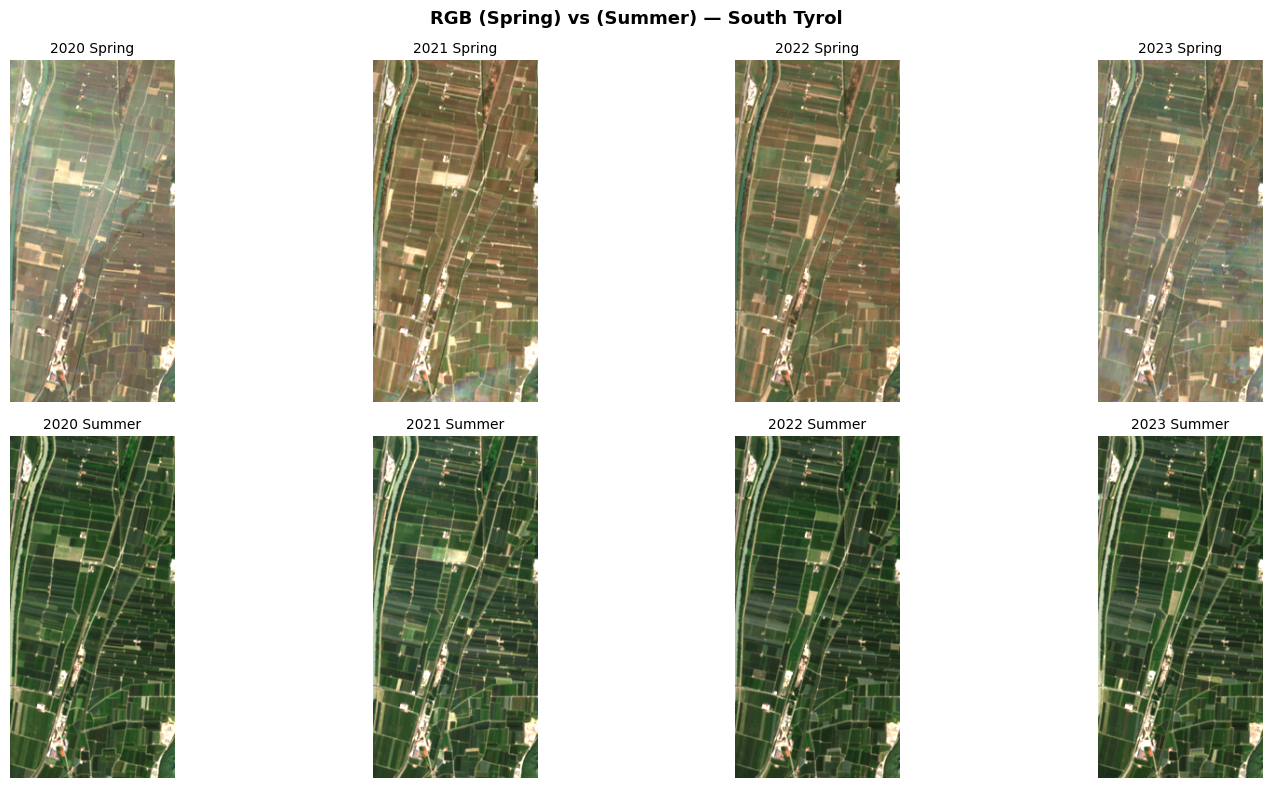

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, year in enumerate(YEARS):
    arr_year = ftw_inputs[year]

    vis_spring = np.transpose(arr_year[[2, 1, 0]], (1, 2, 0))
    vis_spring = np.clip(vis_spring * 3, 0, 1)

    vis_summer = np.transpose(arr_year[[6, 5, 4]], (1, 2, 0))
    vis_summer = np.clip(vis_summer * 3, 0, 1)

    axes[0, col].imshow(vis_spring)
    axes[0, col].set_title(f'{year} Spring', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(vis_summer)
    axes[1, col].set_title(f'{year} Summer', fontsize=10)
    axes[1, col].axis('off')

plt.suptitle('RGB (Spring) vs (Summer) — South Tyrol', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# SAM3

In [39]:
from huggingface_hub import login
login()

## Inference

In [40]:
sam3 = SamGeo3(
    backend='transformers',
    device=None,
    checkpoint_path=None,
    load_from_HF=True
)
print('Sam3 prepared')

Using cuda device and transformers backend


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Sam3 prepared


In [41]:
FIELD_BOXES = [
    [11.3117, 46.3743, 11.3135, 46.3753],
    [11.3008, 46.3718, 11.3032, 46.3744],
    [11.3024, 46.3569, 11.3044, 46.3588],
    [11.2964, 46.3625, 11.2983, 46.3642],
    [11.3130, 46.3869, 11.3150, 46.3883],
    [11.3080, 46.3844, 11.3110, 46.3864],
    [11.2945, 46.3693, 11.2990, 46.3709],
    [11.3072, 46.3589, 11.3109, 46.3615],
    [11.2953, 46.3833, 11.3008, 46.3861],
    [11.2942, 46.3803, 11.2985, 46.3820],
]
BOX_LABELS = [True] * len(FIELD_BOXES)
print(f'{len(FIELD_BOXES)} bounding boxes defined')

10 bounding boxes defined


In [42]:
RUN_INFERENCE = False  # set false if you want pre computed inference

if RUN_INFERENCE:
    def to_uint8_rgb(arr_4ch, clip_pct=2):
        rgb = arr_4ch[:3].astype(np.float32)
        lo  = np.percentile(rgb, clip_pct)
        hi  = np.percentile(rgb, 100 - clip_pct)
        return (np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1) * 255).astype(np.uint8)

    def write_geotiff(rgb_3hw, out_path, H, W, aoi):
        from rasterio.transform import from_bounds
        transform = from_bounds(aoi['west'], aoi['south'],
                                aoi['east'], aoi['north'], W, H)
        with rasterio.open(out_path, 'w', driver='GTiff',
                           height=H, width=W, count=3, dtype='uint8',
                           crs=aoi['crs'], transform=transform, compress='lzw') as dst:
            dst.write(rgb_3hw[0], 1); dst.write(rgb_3hw[1], 2); dst.write(rgb_3hw[2], 3)

    AOI = dict(west=11.290770, south=46.356466, east=11.315060, north=46.389037,
               crs='EPSG:4326')
    H, W = ftw_inputs[YEARS[0]].shape[1], ftw_inputs[YEARS[0]].shape[2]

    # sam3 requires geotiff file.
    seasonal_masks = {}
    sam3_inputs    = {}
    SAM3_TMP_OUT   = 'sam3_tmp_masks'
    os.makedirs(SAM3_TMP_OUT, exist_ok=True)

    for year in YEARS:
        for ts_name, t_arr in [('Spring', spring_rgb[year]), ('Summer', summer_rgb[year])]:
            label     = f'{year}_{ts_name}'
            rgb_3hw   = to_uint8_rgb(t_arr)
            numpy_hwc = rgb_3hw.transpose(1, 2, 0)
            tif_path  = os.path.join(SAM3_TIF_DIR, f'{label}_input_rgb.tif')
            write_geotiff(rgb_3hw, tif_path, H, W, AOI)
            sam3_inputs[label] = {'numpy_hwc': numpy_hwc, 'tif': tif_path}

            sam3.set_image(tif_path)
            sam3.generate_masks_by_boxes(FIELD_BOXES, BOX_LABELS, box_crs='EPSG:4326')

            # saving results
            mask_path = os.path.join(SAM3_TMP_OUT, f'{label}_mask.tif')
            sam3.save_masks(output=mask_path, unique=True)

            with rasterio.open(mask_path) as src:
                mask_arr = src.read(1)
            seasonal_masks[label] = (mask_arr > 0).astype(np.uint8)

            pct = 100 * seasonal_masks[label].mean()
            print(f'  Field pixels: {pct:.1f}%')

    # creating a dict for each year
    raw_results = {}
    for year in YEARS:
        sp = seasonal_masks[f'{year}_Spring'].astype(np.float32)
        su = seasonal_masks[f'{year}_Summer'].astype(np.float32)
        field_prob = (sp + su) / 2.0
        field_mask = (field_prob > 0).astype(np.uint8)
        raw_results[year] = {
            'field_prob'   : field_prob,
            'field_mask'   : field_mask,
            'spring_mask'  : seasonal_masks[f'{year}_Spring'],
            'summer_mask'  : seasonal_masks[f'{year}_Summer'],
        }
        pct = 100 * field_mask.mean()
        print(f' {year}: field coverage {pct:.1f}%')

    with open(SAM3_RESULTS_PKL, 'wb') as f:
        pickle.dump(raw_results, f)

else:
    with open(SAM3_RESULTS_PKL, 'rb') as f:
        raw_results = pickle.load(f)
    print('Loaded pre-computed SAM3 raw results:')
    for year, r in raw_results.items():
        pct = 100 * r['field_mask'].mean()
        print(f'  {year}: field_prob shape {r["field_prob"].shape}, coverage {pct:.1f}%')

Loaded pre-computed SAM3 raw results:
  2020: field_prob shape (368, 177), coverage 49.7%
  2021: field_prob shape (368, 177), coverage 50.9%
  2022: field_prob shape (368, 177), coverage 51.2%
  2023: field_prob shape (368, 177), coverage 54.7%


### Visualizing the mask

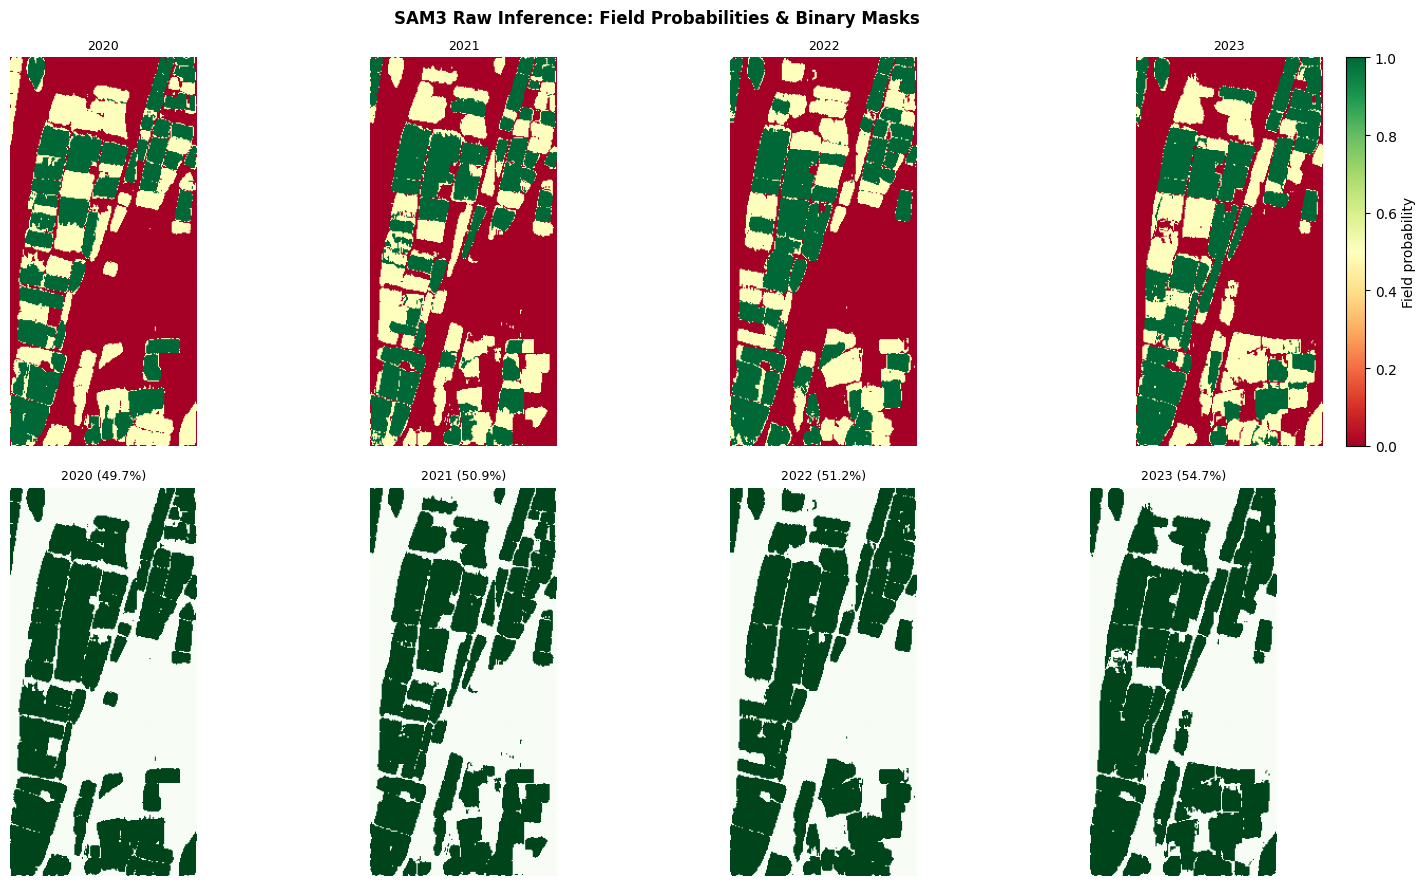

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for col, year in enumerate(YEARS):
    r = raw_results[year]

    im0 = axes[0, col].imshow(r['field_prob'], cmap='RdYlGn', vmin=0, vmax=1)
    axes[0, col].set_title(f'{year}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(r['field_mask'], cmap='Greens')
    pct = 100 * r['field_mask'].mean()
    axes[1, col].set_title(f'{year} ({pct:.1f}%)', fontsize=9)
    axes[1, col].axis('off')

plt.colorbar(im0, ax=axes[0, -1], label='Field probability')
plt.suptitle('SAM3 Raw Inference: Field Probabilities & Binary Masks',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sam3_raw_inference.png'), dpi=150)
plt.show()

## VITO Post Processing
Graph based segmentation: Sobel edges, Felzenszwalb superpixels, RAG, graph cut (threshold=0.15), per-segment field voting applied to SAM3 raw results.

In [44]:
RUN_POSTPROCESS = False  # Set True to rerun VITO filter

if RUN_POSTPROCESS:
    vito_results = postprocess_all_years(
        raw_results,
        scale=120,
        sigma=0.1,
        min_size=10,
        merge_threshold=0.15,
        confidence_threshold=0.2,
        segment_threshold=0.5,
    )
    with open(SAM3_VITO_PKL, 'wb') as f:
        pickle.dump(vito_results, f)
    print(f'Saved VITO results: {SAM3_VITO_PKL}')

else:
    with open(SAM3_VITO_PKL, 'rb') as f:
        vito_results = pickle.load(f)
    print('Loaded VITO-filtered SAM3 results:')
    for year, r in vito_results.items():
        raw_pct  = 100 * raw_results[year]['field_mask'].mean()
        filt_pct = 100 * r['field_mask_smooth'].mean()
        print(f'  {year}: {r["n_segments"]} segments | raw {raw_pct:.1f}% to filtered {filt_pct:.1f}%')

Loaded VITO-filtered SAM3 results:
  2020: 112 segments | raw 49.7% to filtered 31.8%
  2021: 106 segments | raw 50.9% to filtered 30.1%
  2022: 82 segments | raw 51.2% to filtered 35.6%
  2023: 96 segments | raw 54.7% to filtered 37.9%


### Visualizing VITO vs Raw

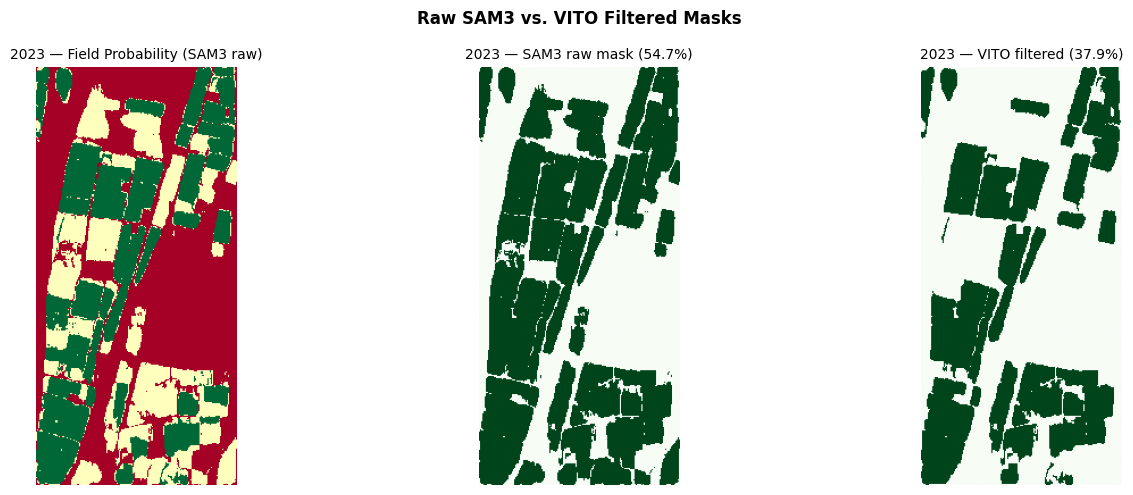

In [45]:
# taking the year 2023
year_show = 2023
r_raw  = raw_results[year_show]
r_vito = vito_results[year_show]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(r_raw['field_prob'], cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title(f'{year_show} — Field Probability (SAM3 raw)', fontsize=10)
axes[0].axis('off')

axes[1].imshow(r_raw['field_mask'], cmap='Greens')
pct_raw = 100 * r_raw['field_mask'].mean()
axes[1].set_title(f'{year_show} — SAM3 raw mask ({pct_raw:.1f}%)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(r_vito['field_mask_smooth'], cmap='Greens')
pct_filt = 100 * r_vito['field_mask_smooth'].mean()
axes[2].set_title(f'{year_show} — VITO filtered ({pct_filt:.1f}%)', fontsize=10)
axes[2].axis('off')

plt.suptitle('Raw SAM3 vs. VITO Filtered Masks', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'sam3_raw_vs_vito_{year_show}.png'), dpi=150)
plt.show()

## Temporal Stability

In [46]:
filt_masks = {yr: r['field_mask_smooth'] for yr, r in vito_results.items()}
raw_masks  = {yr: r['field_mask']         for yr, r in raw_results.items()}

iou_raw      = compute_stability_matrix(raw_masks,  metric='iou')
iou_filtered = compute_stability_matrix(filt_masks, metric='iou')

print('IoU Stability Matrix (VITO-filtered):')
print(iou_filtered.round(4).to_string())

summary_raw  = summarize_stability(iou_raw)
summary = summarize_stability(iou_filtered)

print(f'\nMean IoU  : {summary["mean_iou"]:.4f}')
print(f'Min IoU   : {summary["min_iou"]:.4f}')
print(f'Max IoU   : {summary["max_iou"]:.4f}')
print(f'Std IoU   : {summary["std_iou"]:.4f}')
print(f'Interpret : {summary["interpretation"]}')

# saving summary
stab_summary_df = pd.DataFrame([
    {'source': 'raw',      **summary_raw},
    {'source': 'filtered', **summary},
])
stab_summary_df.to_csv(os.path.join(METRICS_DIR, 'sam3_stability_summary.csv'), index=False)

IoU Stability Matrix (VITO-filtered):
        2020    2021    2022    2023
2020  1.0000  0.4464  0.4341  0.4155
2021  0.4464  1.0000  0.4804  0.4555
2022  0.4341  0.4804  1.0000  0.5159
2023  0.4155  0.4555  0.5159  1.0000

Mean IoU  : 0.4580
Min IoU   : 0.4155
Max IoU   : 0.5159
Std IoU   : 0.0326
Interpret : Significant boundary instability


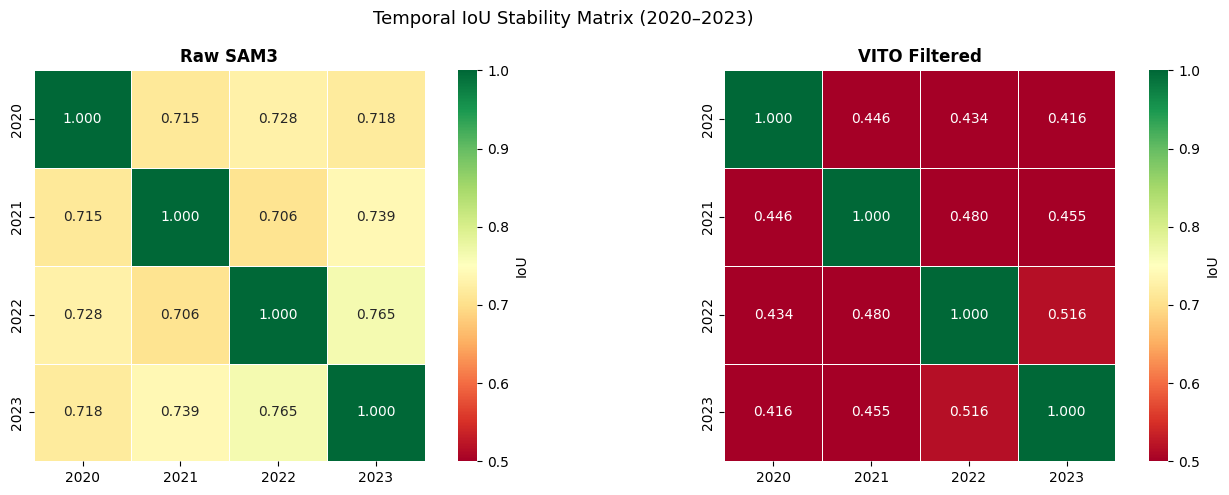

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, iou_df, title in [
    (axes[0], iou_raw,      'Raw SAM3'),
    (axes[1], iou_filtered, 'VITO Filtered'),
]:
    sns.heatmap(
        iou_df, annot=True, fmt='.3f', cmap='RdYlGn',
        vmin=0.5, vmax=1.0, ax=ax, cbar_kws={'label': 'IoU'},
        square=True, linewidths=0.5
    )
    ax.set_title(f'{title}', fontweight='bold')

plt.suptitle('Temporal IoU Stability Matrix (2020–2023)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sam3_stability_matrix_comparison.png'), dpi=150)
plt.show()

In [48]:
change_df_raw  = multi_year_change_analysis(raw_masks)
change_df_filt = multi_year_change_analysis(filt_masks)

display_cols = ['transition', 'added_pct', 'removed_pct', 'stable_field_pct',
                'changed_pct', 'net_change_pct']
print('Change Analysis (VITO-filtered):')
print(change_df_filt[display_cols].round(2).to_string(index=False))

change_df_raw.to_csv(os.path.join(METRICS_DIR,  'sam3_change_analysis_raw.csv'),      index=False)
change_df_filt.to_csv(os.path.join(METRICS_DIR, 'sam3_change_analysis_filtered.csv'), index=False)

Change Analysis (VITO-filtered):
transition  added_pct  removed_pct  stable_field_pct  changed_pct  net_change_pct
 2020-2021      10.97        12.72             19.10        23.69           -1.75
 2021-2022      14.31         8.75             21.32        23.06            5.56
 2022-2023      12.91        10.59             25.04        23.50            2.32


## Stability Zone Classification

In [49]:
# Stability zone classification
stab_class, freq_map = classify_stability_zones(raw_masks, stable_threshold=0.8)
persistence = compute_persistence_index(raw_masks)

n_pixels   = stab_class.size
never_pct  = 100 * (stab_class == 0).sum() / n_pixels
always_pct = 100 * (stab_class == 1).sum() / n_pixels
some_pct   = 100 * (stab_class == 2).sum() / n_pixels

print('Stability Zone Classification (SAM3 + VITO-filtered):')
print(f'  Never field    : {never_pct:.1f}%')
print(f'  Always field   : {always_pct:.1f}%')
print(f'  Sometimes field: {some_pct:.1f}%')
print(f'\nPersistence index: mean={persistence.mean():.3f}, median={np.median(persistence):.3f}')

zones_df = pd.DataFrame([{
    'source'            : 'filtered',
    'never_field_pct'   : never_pct,
    'always_field_pct'  : always_pct,
    'sometimes_field_pct': some_pct,
    'persistence_mean'  : float(persistence.mean()),
    'persistence_median': float(np.median(persistence)),
}])
zones_df.to_csv(os.path.join(METRICS_DIR, 'sam3_stability_zones.csv'), index=False)

Stability Zone Classification (SAM3 + VITO-filtered):
  Never field    : 34.9%
  Always field   : 35.7%
  Sometimes field: 29.4%

Persistence index: mean=0.808, median=1.000


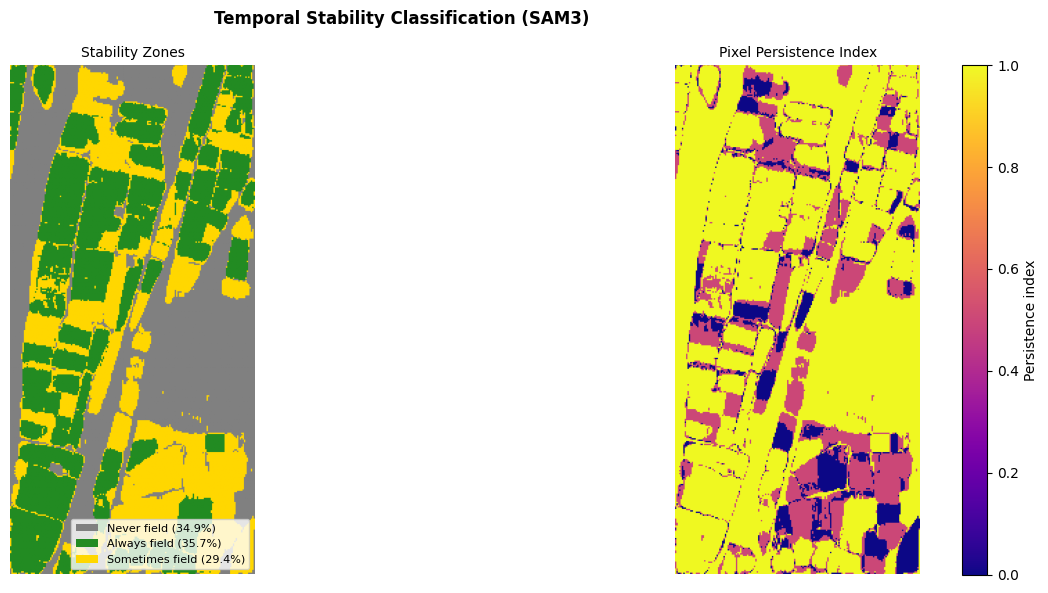

In [50]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

cmap_stab = ListedColormap(['#808080', '#228B22', '#FFD700'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(stab_class, cmap=cmap_stab, vmin=0, vmax=2)
axes[0].set_title('Stability Zones', fontsize=10)
axes[0].axis('off')
legend_elements = [
    mpatches.Patch(facecolor='#808080', label=f'Never field ({never_pct:.1f}%)'),
    mpatches.Patch(facecolor='#228B22', label=f'Always field ({always_pct:.1f}%)'),
    mpatches.Patch(facecolor='#FFD700', label=f'Sometimes field ({some_pct:.1f}%)'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

im1 = axes[1].imshow(persistence, cmap='plasma', vmin=0, vmax=1)
axes[1].set_title('Pixel Persistence Index', fontsize=10)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='Persistence index')

plt.suptitle('Temporal Stability Classification (SAM3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sam3_stability_zones.png'), dpi=150)
plt.show()

## Validation against Cadastral Parcels

In [51]:
gdf_cadastre = load_cadastre(CADASTRE_SHP, aoi_bbox=AOI_BBOX)
gt_mask = rasterize_parcels(gdf_cadastre, parcel_type='T')

print(f'Loaded {len(gdf_cadastre)} cadastral parcels')
print(f'Ground truth mask shape: {gt_mask.shape}')
print(f'Ground truth field coverage: {100*gt_mask.mean():.1f}%')

Loaded 1466 cadastral parcels
Ground truth mask shape: (368, 177)
Ground truth field coverage: 96.1%


In [52]:
RUN_VALIDATION = False  # Set True to recompute all validation metrics

if RUN_VALIDATION:
    report = generate_full_report(
        raw_results=raw_results,
        filtered_results=vito_results,
        gdf=gdf_cadastre,
        output_dir=METRICS_DIR,
    )
    with open(SAM3_VAL_PKL, 'wb') as f:
        pickle.dump(report, f)
    print(f'Saved validation report: {SAM3_VAL_PKL}')

else:
    with open(SAM3_VAL_PKL, 'rb') as f:
        report = pickle.load(f)
    print('Loaded pre-computed SAM3 validation report.')

Loaded pre-computed SAM3 validation report.


In [53]:
pixel_df = pd.read_csv(os.path.join(METRICS_DIR, 'pixel_metrics.csv'))

summary_cols = ['year', 'source', 'precision', 'recall', 'f1', 'iou', 'accuracy']
print('Pixel-level Validation Metrics:')
print(pixel_df[summary_cols].round(4).to_string(index=False))

Pixel-level Validation Metrics:
 year   source  precision  recall     f1    iou  accuracy
 2020      raw     0.9829  0.5084 0.6702 0.5039    0.5193
 2020 filtered     0.9941  0.3293 0.4947 0.3286    0.3538
 2021      raw     0.9864  0.5228 0.6834 0.5190    0.5347
 2021 filtered     0.9896  0.3098 0.4718 0.3088    0.3338
 2022      raw     0.9831  0.5236 0.6833 0.5190    0.5338
 2022 filtered     0.9846  0.3652 0.5327 0.3631    0.3847
 2023      raw     0.9831  0.5593 0.7130 0.5540    0.5675
 2023 filtered     0.9904  0.3913 0.5609 0.3898    0.4116


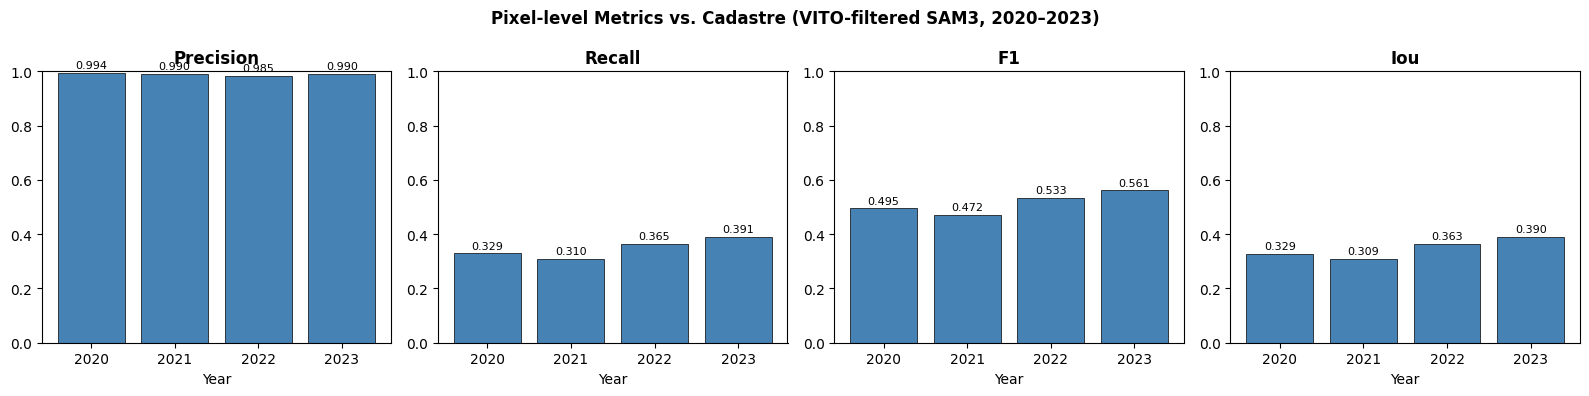

In [54]:
filt_df = pixel_df[pixel_df['source'] == 'filtered'].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, metric in zip(axes, ['precision', 'recall', 'f1', 'iou']):
    ax.bar(filt_df['year'], filt_df[metric], color='steelblue', edgecolor='k', linewidth=0.5)
    ax.set_title(metric.capitalize(), fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylim(0, 1)
    ax.set_xticks(YEARS)
    for bar, val in zip(ax.patches, filt_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Pixel-level Metrics vs. Cadastre (VITO-filtered SAM3, 2020–2023)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sam2_pixel_metrics_bar.png'), dpi=150)
plt.show()

In [55]:
bm_df  = pd.read_csv(os.path.join(METRICS_DIR, 'boundary_metrics.csv'))
bm_filt = bm_df[bm_df['source'] == 'filtered']

display_cols = ['year', 'boundary_f1_10m', 'boundary_f1_20m', 'boundary_f1_30m',
                'boundary_recall_30m']
print('Boundary Metrics (VITO-filtered SAM3):')
print(bm_filt[display_cols].round(4).to_string(index=False))

Boundary Metrics (VITO-filtered SAM3):
 year  boundary_f1_10m  boundary_f1_20m  boundary_f1_30m  boundary_recall_30m
 2020           0.1013           0.1550           0.2003               0.3216
 2021           0.1012           0.1679           0.2180               0.3396
 2022           0.1493           0.2178           0.2743               0.4431
 2023           0.1276           0.2051           0.2607               0.4346


## Vectorization and Interactive Map

In [58]:
gdfs = {}
for year in YEARS:
    path = os.path.join(OUTPUT_DIR, f'sam3_parcels_{year}.geojson')
    if os.path.exists(path):
        gdfs[year] = gpd.read_file(path)
        print(f'{year}: loaded {len(gdfs[year])} polygons from {path}')
    else:
        r = vito_results[year]
        gdfs[year] = vectorize_segments(
            r['segments'], r['field_mask_smooth'],
            simplify_tolerance=5.0, output_path=path
        )
        print(f'{year}: vectorized {len(gdfs[year])} polygons → {path}')

2020: loaded 54 polygons from /content/drive/MyDrive/pheno-boundary/data/outputs/sam3_parcels_2020.geojson
2021: loaded 58 polygons from /content/drive/MyDrive/pheno-boundary/data/outputs/sam3_parcels_2021.geojson
2022: loaded 59 polygons from /content/drive/MyDrive/pheno-boundary/data/outputs/sam3_parcels_2022.geojson
2023: loaded 45 polygons from /content/drive/MyDrive/pheno-boundary/data/outputs/sam3_parcels_2023.geojson


In [59]:
# statistics summary
print(f'{"Year":<6} {"Polygons":<10} {"Total Area (ha)":<18} {"Mean Area (m²)":<16} {"Median Area (m²)"}')
print('-' * 65)
for year in YEARS:
    gdf      = gdfs[year]
    total_ha = gdf['area_m2'].sum() / 1e4
    mean_m2  = gdf['area_m2'].mean()
    med_m2   = gdf['area_m2'].median()
    print(f'{year:<6} {len(gdf):<10} {total_ha:<18.1f} {mean_m2:<16.0f} {med_m2:.0f}')

Year   Polygons   Total Area (ha)    Mean Area (m²)   Median Area (m²)
-----------------------------------------------------------------
2020   54         207.3              38381            18800
2021   58         195.9              33769            16000
2022   59         232.1              39334            13900
2023   45         247.2              54931            24000


In [60]:
# folium map:
best_year, mean_ious, iou_matrix = find_most_stable_year(vito_results)
print(f'Most stable year: {best_year}')
print('Mean IoU per year:')
for yr, val in sorted(mean_ious.items()):
    marker = '  ← most stable' if yr == best_year else ''
    print(f'  {yr}: {val:.4f}{marker}')

gdf_cad_wgs84 = gpd.read_file(os.path.join(OUTPUT_DIR, 'cadastre_clipped.geojson'))

html_path = os.path.join(OUTPUT_DIR, 'sam3_interactive_map.html')
m = create_interactive_map(
    gdf_ftw=gdfs[best_year],
    gdf_cadastre=gdf_cad_wgs84,
    best_year=best_year,
    output_html=html_path,
)
print(f'Interactive map also saved: {html_path}')

Most stable year: 2022
Mean IoU per year:
  2020: 0.4320
  2021: 0.4608
  2022: 0.4768  ← most stable
  2023: 0.4623
  Saved interactive map: /content/drive/MyDrive/pheno-boundary/data/outputs/sam3_interactive_map.html
Interactive map also saved: /content/drive/MyDrive/pheno-boundary/data/outputs/sam3_interactive_map.html


In [61]:
from IPython.display import IFrame, display
if os.path.exists(html_path):
    display(IFrame(src=html_path, width=800, height=600))
else:
    print(f"Error: File not found at {html_path}")

## Summary

In [62]:
print('PHENO-BOUNDARY — SAM3 FINAL RESULTS SUMMARY\n\n')
print('INFERENCE (SAM3 + VITO-filtered)')
print(f'  Years processed    : {YEARS}')
print(f'  Output resolution  : 10 m')
print(f'  BBox prompts       : {len(FIELD_BOXES)} field boxes\n')

print('PIXEL-LEVEL VALIDATION (vs. Cadastral Land Parcels)')
for _, row in filt_df.iterrows():
    print(f'  {int(row.year)}: P={row.precision:.3f}  R={row.recall:.3f}  F1={row.f1:.3f}  IoU={row.iou:.3f}')

print('\nTEMPORAL STABILITY')
print(f'  Mean IoU           : {summary["mean_iou"]:.4f}')
print(f'  Range              : [{summary["min_iou"]:.4f}, {summary["max_iou"]:.4f}]')
print(f'  Interpretation     : {summary["interpretation"]}')

print('\nSTABILITY ZONES')
print(f'  Never field        : {never_pct:.1f}%')
print(f'  Always field       : {always_pct:.1f}%')
print(f'  Sometimes field    : {some_pct:.1f}%')

print('\nCHANGE ANALYSIS')
for _, row in change_df_filt[['transition','added_pct','removed_pct','stable_field_pct']].iterrows():
    print(f'  {row.transition}: +{row.added_pct:.1f}% / -{row.removed_pct:.1f}% | stable {row.stable_field_pct:.1f}%')

print('\nVECTOR OUTPUTS')
for year in YEARS:
    gdf = gdfs[year]
    print(f'  {year}: {len(gdf)} polygons, {gdf["area_m2"].sum()/1e4:.0f} ha total')

PHENO-BOUNDARY — SAM3 FINAL RESULTS SUMMARY


INFERENCE (SAM3 + VITO-filtered)
  Years processed    : [2020, 2021, 2022, 2023]
  Output resolution  : 10 m
  BBox prompts       : 10 field boxes

PIXEL-LEVEL VALIDATION (vs. Cadastral Land Parcels)
  2020: P=0.994  R=0.329  F1=0.495  IoU=0.329
  2021: P=0.990  R=0.310  F1=0.472  IoU=0.309
  2022: P=0.985  R=0.365  F1=0.533  IoU=0.363
  2023: P=0.990  R=0.391  F1=0.561  IoU=0.390

TEMPORAL STABILITY
  Mean IoU           : 0.4580
  Range              : [0.4155, 0.5159]
  Interpretation     : Significant boundary instability

STABILITY ZONES
  Never field        : 34.9%
  Always field       : 35.7%
  Sometimes field    : 29.4%

CHANGE ANALYSIS
  2020-2021: +11.0% / -12.7% | stable 19.1%
  2021-2022: +14.3% / -8.8% | stable 21.3%
  2022-2023: +12.9% / -10.6% | stable 25.0%

VECTOR OUTPUTS
  2020: 54 polygons, 207 ha total
  2021: 58 polygons, 196 ha total
  2022: 59 polygons, 232 ha total
  2023: 45 polygons, 247 ha total


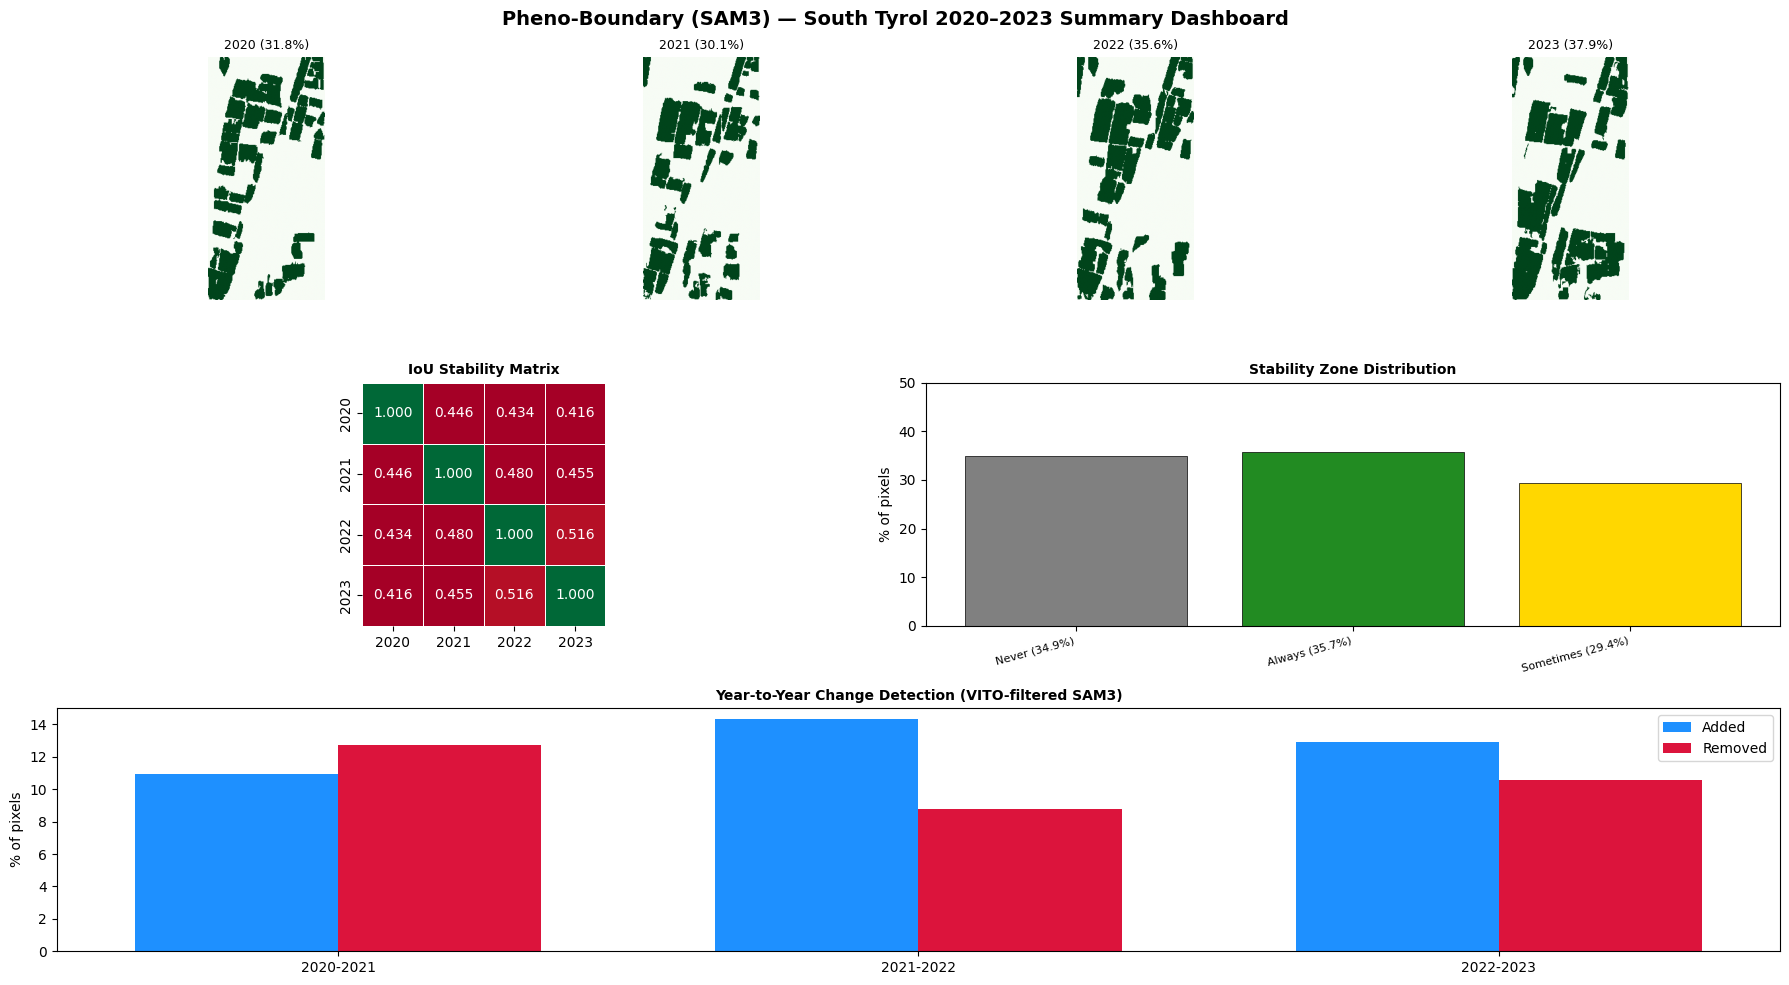


SAM3 pipeline complete. All outputs saved to: /content/drive/MyDrive/pheno-boundary/data/outputs


In [63]:
# all together dashboard
fig = plt.figure(figsize=(18, 10))

for i, year in enumerate(YEARS):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.imshow(vito_results[year]['field_mask_smooth'], cmap='Greens')
    pct = 100 * vito_results[year]['field_mask_smooth'].mean()
    ax.set_title(f'{year} ({pct:.1f}%)', fontsize=9)
    ax.axis('off')

ax_iou = fig.add_subplot(3, 4, (5, 6))
sns.heatmap(iou_filtered, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1, ax=ax_iou, cbar=False, square=True, linewidths=0.5)
ax_iou.set_title('IoU Stability Matrix', fontweight='bold', fontsize=10)

ax_zones = fig.add_subplot(3, 4, (7, 8))
zone_labels = [f'Never ({never_pct:.1f}%)', f'Always ({always_pct:.1f}%)', f'Sometimes ({some_pct:.1f}%)']
zone_values = [never_pct, always_pct, some_pct]
zone_colors = ['#808080', '#228B22', '#FFD700']
ax_zones.bar(zone_labels, zone_values, color=zone_colors, edgecolor='k', linewidth=0.5)
ax_zones.set_title('Stability Zone Distribution', fontweight='bold', fontsize=10)
ax_zones.set_ylabel('% of pixels')
ax_zones.set_ylim(0, 50)
plt.setp(ax_zones.get_xticklabels(), rotation=15, ha='right', fontsize=8)

ax_change = fig.add_subplot(3, 1, 3)
x = range(len(change_df_filt))
w = 0.35
ax_change.bar([i - w/2 for i in x], change_df_filt['added_pct'],   width=w, label='Added',   color='#1E90FF')
ax_change.bar([i + w/2 for i in x], change_df_filt['removed_pct'], width=w, label='Removed', color='#DC143C')
ax_change.set_xticks(list(x))
ax_change.set_xticklabels(change_df_filt['transition'])
ax_change.set_ylabel('% of pixels')
ax_change.set_title('Year-to-Year Change Detection (VITO-filtered SAM3)', fontweight='bold', fontsize=10)
ax_change.legend()
ax_change.set_ylim(0, 15)

plt.suptitle('Pheno-Boundary (SAM3) — South Tyrol 2020–2023 Summary Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sam3_summary_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nSAM3 pipeline complete. All outputs saved to:', OUTPUT_DIR)